In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Weather Data

In [4]:
df = pd.read_csv(r'C:\Users\HP\Desktop\Đồ án\src\data\era5_data.csv')
df.head()

,valid_time,u10,v10,t2m,tp,latitude,longitude
0,2020-01-01 00:00:00,-1.420044,-2.713821,296.23346,0.0,10.75,106.25
1,2020-01-01 01:00:00,-1.786804,-2.769379,297.98633,0.0,10.75,106.25
2,2020-01-01 02:00:00,-2.413864,-2.801300,301.89752,0.0,10.75,106.25
3,2020-01-01 03:00:00,-2.574707,-2.350678,302.15576,0.0,10.75,106.25
4,2020-01-01 04:00:00,-2.324310,-1.983063,303.06354,0.0,10.75,106.25


In [42]:
df["wind_speed"] = np.sqrt(df["u10"]**2 + df["v10"]**2)

df["temp"] = df["t2m"] - 273.15

df["total_precipitation"] = df["tp"]*1000

df_cleaned = df[["valid_time", "wind_speed","temp","total_precipitation"]]

print(df_cleaned.head())
df_cleaned.to_csv(r'C:\Users\HP\Desktop\Đồ án\src\data\processed_data\CauNoi_data\Weather_2020_2025.csv', index=False, encoding='utf-8-sig')

            valid_time  wind_speed      temp  total_precipitation
0  2020-01-01 00:00:00    3.062899  23.08346                  0.0
1  2020-01-01 01:00:00    3.295774  24.83633                  0.0
2  2020-01-01 02:00:00    3.697840  28.74752                  0.0
3  2020-01-01 03:00:00    3.486374  29.00576                  0.0
4  2020-01-01 04:00:00    3.055316  29.91354                  0.0


Merging Data

In [54]:
xls = pd.read_excel(r'C:\Users\HP\Desktop\Đồ án\src\data\SO LIEU MAN DBSCL_2020-2025\NAM 2020\LONGAN2020\LONGAN2020\TANAN-2020-new.xls', sheet_name=None)

print("Danh sách tên sheet:")
for i, name in enumerate(xls.keys()):
    print(f"  {i}: '{name}' | repr: {repr(name)}")

Danh sách tên sheet:
  0: 'mtd-1' | repr: 'mtd-1'
  1: 'mtd-2' | repr: 'mtd-2'
  2: 'mtd-3' | repr: 'mtd-3'
  3: 'mtd-4' | repr: 'mtd-4'
  4: 'mtd-5' | repr: 'mtd-5'
  5: 'mtd-6' | repr: 'mtd-6'
  6: ' mangio-1' | repr: ' mangio-1'
  7: 'mangio-2' | repr: 'mangio-2'
  8: 'mangio-3' | repr: 'mangio-3'
  9: 'mangio-4' | repr: 'mangio-4'
  10: 'mangio-5' | repr: 'mangio-5'
  11: 'mangio-6' | repr: 'mangio-6'
  12: 'dmdt' | repr: 'dmdt'
  13: 'Hgio-1' | repr: 'Hgio-1'
  14: 'Hgio-2' | repr: 'Hgio-2'
  15: 'Hgio-3' | repr: 'Hgio-3'
  16: 'Hgio-4' | repr: 'Hgio-4'
  17: 'Hgio-5' | repr: 'Hgio-5'
  18: 'Hgio-6' | repr: 'Hgio-6'


In [59]:
import pandas as pd

def dong_bo_du_lieu_thuy_van(file_path):
    """
    Hàm tự động quét toàn bộ file Excel, bóc tách Độ mặn và Mực nước, 
    trải phẳng dữ liệu và ghép nối thành một chuỗi thời gian duy nhất.
    """
    xls = pd.read_excel(file_path, sheet_name=None)
    
    df_salinity_list = []
    df_water_level_list = []
    
    for sheet_name, df in xls.items():
        
        if not (sheet_name.startswith('mangio') or sheet_name.startswith(' mangio') or sheet_name.startswith('1.Cầu Nổi') or sheet_name.startswith('CauNoi') or sheet_name.startswith('BenLuc') or sheet_name.startswith('TanAn')):
            continue
            
        
        header_idx = -1
        for i in range(min(15, len(df))):
            if 'Ngày' in str(df.iloc[i, 0]):
                header_idx = i
                # print(f"Header found at row: {header_idx} in sheet: {sheet_name}")
                break
                
        if header_idx == -1: continue 
        
        
        df.columns = df.iloc[header_idx]
        df = df.iloc[header_idx+1:].reset_index(drop=True)
        df.rename(columns={df.columns[0]: 'Ngay'}, inplace=True)
        
        
        df = df.dropna(subset=['Ngay'])
        
        gio_cols = [col for col in df.columns if str(col).strip() in 
                    ['1.0', '3.0', '5.0', '7.0', '9.0', '11.0', '13.0', '15.0', '17.0', '19.0', '21.0', '23.0',
                     '1', '3', '5', '7', '9', '11', '13', '15', '17', '19', '21', '23']]
        df = df[['Ngay'] + gio_cols]
        
        
        df_melted = df.melt(id_vars=['Ngay'], var_name='Gio', value_name='GiaTri')
        df_melted = df_melted.dropna(subset=['GiaTri']) 
        
        
        def parse_date(d):
            if isinstance(d, pd.Timestamp): return d
            try: 
                
                return pd.to_datetime(float(d), unit='D', origin='1899-12-30') 
            except: 
                return pd.to_datetime(d, errors='coerce')
            
        df_melted['Ngay'] = df_melted['Ngay'].apply(parse_date)
        df_melted = df_melted.dropna(subset=['Ngay']) 
        
        
        df_melted['Gio'] = df_melted['Gio'].astype(str).str.replace('.0', '', regex=False).astype(int)
        
       
        df_melted['Time'] = df_melted.apply(lambda row: row['Ngay'] + pd.Timedelta(hours=row['Gio']), axis=1)
        
        
        if sheet_name.startswith('mangio') or sheet_name.startswith(' mangio') or sheet_name.startswith('1.Cầu Nổi') or sheet_name.startswith('CauNoi') or sheet_name.startswith('BenLuc') or sheet_name.startswith('TanAn'):
            df_melted = df_melted.rename(columns={'GiaTri': 'Salinity_CauNoi'})
            df_salinity_list.append(df_melted[['Time', 'Salinity_CauNoi']])

    
    df_salinity_tong = pd.concat(df_salinity_list, ignore_index=True)
    
   
    
    return df_salinity_tong.sort_values('Time').reset_index(drop=True)

df_tram_benluc = dong_bo_du_lieu_thuy_van(r'C:\Users\HP\Desktop\Đồ án\src\data\SO LIEU MAN DBSCL_2020-2025\NAM 2025\SỐ LIỆU MẶN LONG AN_DKTTV.xlsx')


print(df_tram_benluc.head())
print(f"Tổng số bản ghi thu được: {len(df_tram_benluc)} dòng.")
df_tram_benluc.to_csv(r'C:\Users\HP\Desktop\Đồ án\src\data\processed_data\TanAn_data\TanAn_2025.csv', index=False, encoding='utf-8-sig')

                 Time Salinity_CauNoi
0 2025-01-01 01:00:00             4.8
1 2025-01-01 01:00:00             0.1
2 2025-01-01 01:00:00             0.2
3 2025-01-01 03:00:00             0.1
4 2025-01-01 03:00:00             0.3
Tổng số bản ghi thu được: 5424 dòng.


In [60]:
import glob

folder_path = r"C:\Users\HP\Desktop\Đồ án\src\data\processed_data\TanAn_data"

all_files = glob.glob(f"{folder_path}/*.csv")

df_list = [pd.read_csv(file) for file in all_files]
df_combined = pd.concat(df_list, ignore_index=True)

df_combined = df_combined.sort_values('Time').reset_index(drop=True)

df_combined.to_csv(r'C:\Users\HP\Desktop\Đồ án\src\data\processed_data\TanAn_data\TanAn_2020_2025.csv', index=False, encoding='utf-8-sig')

In [61]:
df_combined['Time'] = pd.to_datetime(df_combined['Time'])
df_cleaned['valid_time'] = pd.to_datetime(df_cleaned['valid_time'])

df_final = pd.merge(df_combined, df_cleaned, left_on='Time', right_on='valid_time', how='inner')

df_final = df_final.drop(columns=['valid_time'])
df_final
df_final.to_csv(r'C:\Users\HP\Desktop\Đồ án\src\data\processed_data\TanAn_data\TanAn_Weather_2020_2025.csv', index=False, encoding='utf-8-sig')

Preprocessing Data


In [3]:
df_pre = pd.read_csv(r'C:\Users\HP\Desktop\Đồ án\src\data\processed_data\CauNoi_data\CauNoi_Weather_2020_2025.csv')
df_pre['Time'] = pd.to_datetime(df_pre['Time'])
df_pre = df_pre.sort_values('Time')

processed_years = []
years = df_pre['Time'].dt.year.unique()
numeric_cols = ['Salinity_CauNoi', 'wind_speed', 'temp', 'total_precipitation']

train_dfs = []
valid_dfs = []
test_dfs = []
for year in years:
    if year == 2024:
        continue
    df_year = df_pre[df_pre['Time'].dt.year == year].copy()
    df_year = df_year.set_index('Time')
    
    df_year[numeric_cols] = df_year[numeric_cols].apply(pd.to_numeric, errors='coerce')
    df_year = df_year.resample('2h', offset='1h').mean()
    
    df_year['is_imputed'] = df_year['Salinity_CauNoi'].isna().astype(int)

    for col in numeric_cols:
        df_year[col] = df_year.groupby(df_year.index.hour)[col].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))

    df_year = df_year.reset_index()

    hours = df_year['Time'].dt.hour
    day_of_year = df_year['Time'].dt.dayofyear

    df_year['hour_sin'] = np.sin(2 * np.pi * hours / 24)
    df_year['hour_cos'] = np.cos(2 * np.pi * hours / 24)
    df_year['day_sin'] = np.sin(2 * np.pi * day_of_year / 365)
    df_year['day_cos'] = np.cos(2 * np.pi * day_of_year / 365)

    processed_years.append(df_year)

# for year in processed_years:
#     if year['Time'].dt.year.iloc[0] < 2023:
#         train_dfs.append(year)
#     elif year['Time'].dt.year.iloc[0] == 2023:
#         valid_dfs.append(year)
#     else:
#         test_dfs.append(year)
# df_train = pd.concat(train_dfs, ignore_index=True)
# df_valid = pd.concat(valid_dfs, ignore_index=True)
# df_test = pd.concat(test_dfs, ignore_index=True)


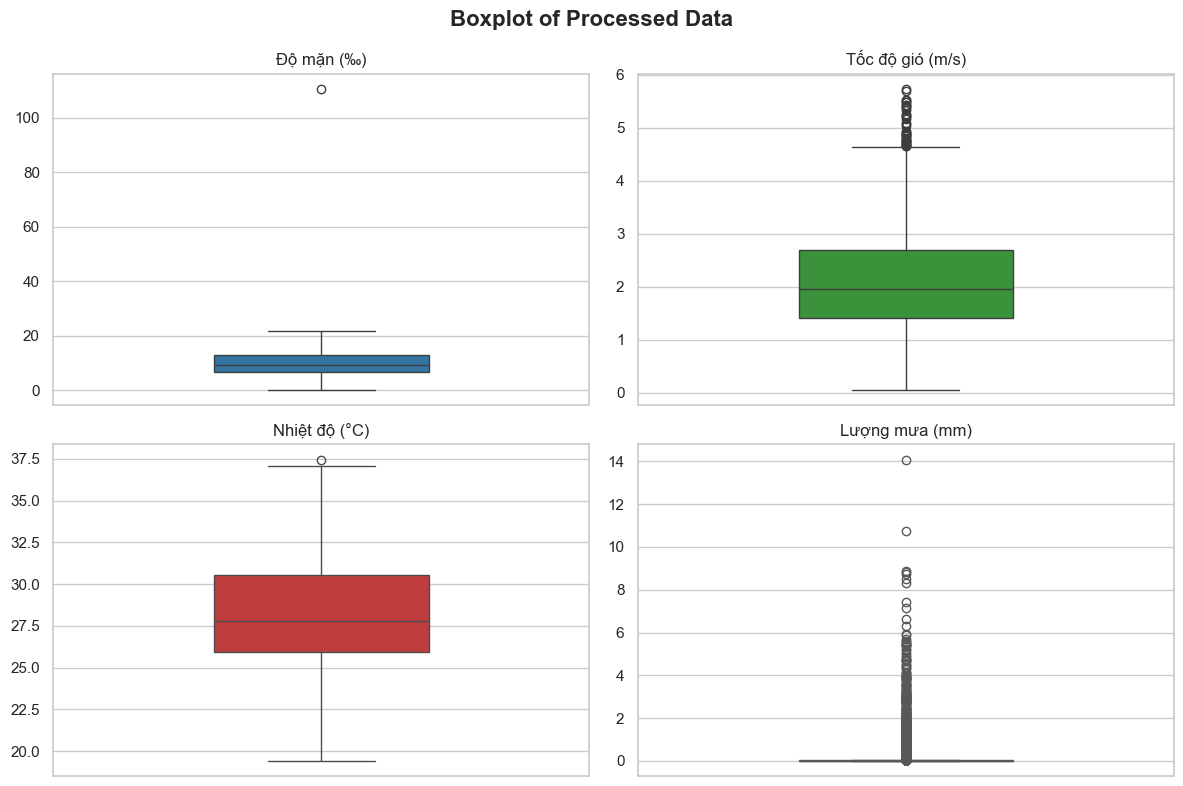

In [5]:
df_all = pd.concat(processed_years, ignore_index=True)

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,8))
fig.suptitle('Boxplot of Processed Data', fontsize=16, fontweight='bold')

colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']
titles = ['Độ mặn (‰)', 'Tốc độ gió (m/s)', 'Nhiệt độ (°C)', 'Lượng mưa (mm)']

for i,col in enumerate(numeric_cols):
    row, col_idx = divmod(i, 2)
    sns.boxplot(y=df_all[col], ax=axes[row, col_idx], color=colors[i], width=0.4)
    axes[row, col_idx].set_title(titles[i], fontsize=12)
    axes[row, col_idx].set_ylabel('')

plt.tight_layout()
plt.show()
    

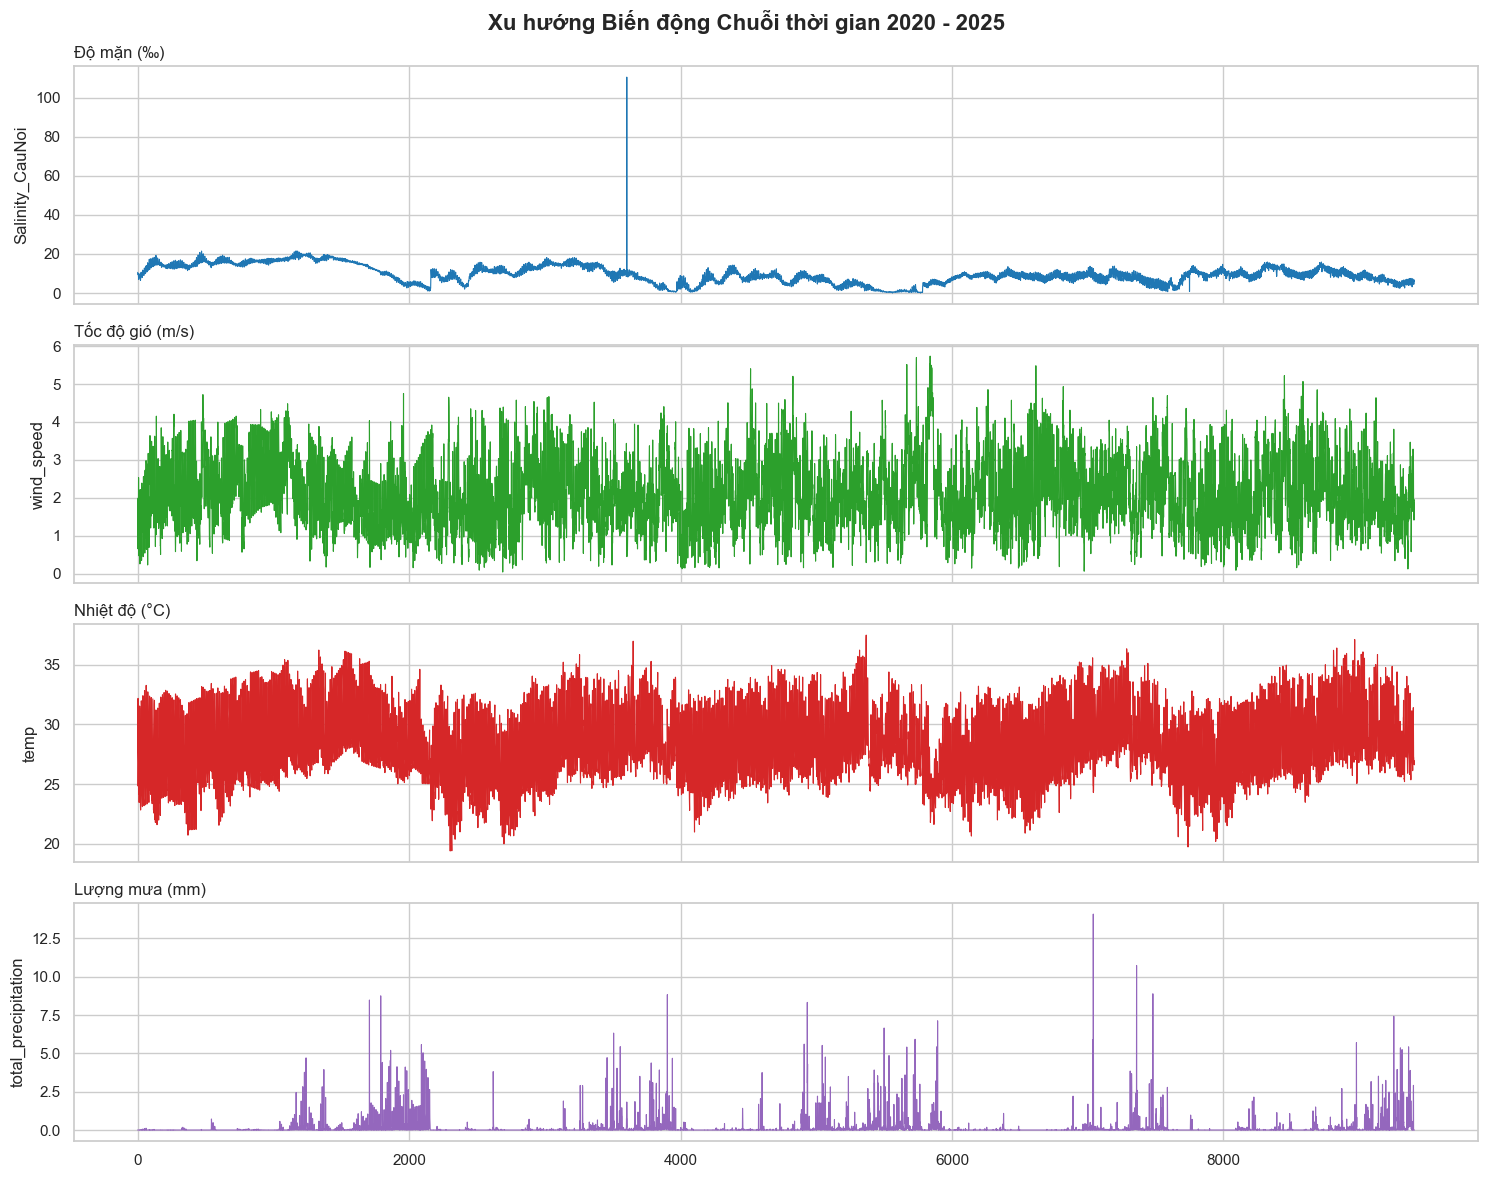

In [6]:
fig2, axes2 = plt.subplots(nrows=4, ncols=1, figsize=(15, 12), sharex=True)
fig2.suptitle('Xu hướng Biến động Chuỗi thời gian 2020 - 2025', fontsize=16, fontweight='bold')

for i, col in enumerate(numeric_cols):
    axes2[i].plot(df_all.index, df_all[col], color=colors[i], linewidth=0.8)
    axes2[i].set_title(titles[i], loc='left', fontsize=12)
    axes2[i].set_ylabel(col)

plt.tight_layout()
plt.show()


In [7]:
# --- Biểu đồ 3: Zoom chi tiết 1 tháng xem chu kỳ thủy triều ---
plt.figure(figsize=(15, 4))
df_zoom = df_all[(df_all.index.year == 2021) & (df_all.index.month == 4)] # Zoom vào tháng 4/2021

plt.plot(df_zoom.index, df_zoom['Salinity_CauNoi'], color='#1f77b4', marker='.', linestyle='-')
plt.title('Chi tiết Độ mặn trong Tháng 04/2021 (Răng cưa thủy triều lên xuống)', fontsize=14)
plt.ylabel('Độ mặn (‰)')
plt.xlabel('Thời gian')
plt.tight_layout()
plt.show()

AttributeError: 'RangeIndex' object has no attribute 'year'

<Figure size 1500x400 with 0 Axes>